In [ ]:
# import kagglehub
# import shutil
# import os

In [ ]:
# # Download dataset
# path = kagglehub.dataset_download("bhandariprakanda/meld-emotion-recognition")

# print("Downloaded to:", path)

100%|██████████| 10.1G/10.1G [02:00<00:00, 90.7MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/bhandariprakanda/meld-emotion-recognition/versions/9


In [ ]:
# # Destination in Google Drive
# destination = "/content/drive/MyDrive/MELD"

# # Create folder if not exists
# os.makedirs(destination, exist_ok=True)

# # Copy dataset to Drive
# shutil.copytree(path, destination, dirs_exist_ok=True)

# print("Dataset saved to:", destination)

Dataset saved to: /content/drive/MyDrive/MELD


In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/MELD/MELD.Raw/MELD.Raw/train/train_sent_emo.csv")
dev_df = pd.read_csv("/content/drive/MyDrive/MELD/MELD.Raw/MELD.Raw/dev_sent_emo.csv")
test_df = pd.read_csv("/content/drive/MyDrive/MELD/MELD.Raw/MELD.Raw/test_sent_emo.csv")

In [ ]:
print(train_df.columns)

Index(['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID',
       'Utterance_ID', 'Season', 'Episode', 'StartTime', 'EndTime'],
      dtype='object')


In [ ]:
train_df.head()

,Sr No.,Utterance,Speaker,Emotion,Sentiment,Dialogue_ID,Utterance_ID,Season,Episode,StartTime,EndTime
0,1,also I was the point person on my companys tr...,Chandler,neutral,neutral,0,0,8,21,"00:16:16,059","00:16:21,731"
1,2,You mustve had your hands full.,The Interviewer,neutral,neutral,0,1,8,21,"00:16:21,940","00:16:23,442"
2,3,That I did. That I did.,Chandler,neutral,neutral,0,2,8,21,"00:16:23,442","00:16:26,389"
3,4,So lets talk a little bit about your duties.,The Interviewer,neutral,neutral,0,3,8,21,"00:16:26,820","00:16:29,572"
4,5,My duties? All right.,Chandler,surprise,positive,0,4,8,21,"00:16:34,452","00:16:40,917"


In [ ]:
train_df = train_df[['Utterance', 'Emotion']]
dev_df = dev_df[['Utterance', 'Emotion']]
test_df = test_df[['Utterance', 'Emotion']]

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df['label'] = label_encoder.fit_transform(train_df['Emotion'])
dev_df['label'] = label_encoder.transform(dev_df['Emotion'])
test_df['label'] = label_encoder.transform(test_df['Emotion'])

print(label_encoder.classes_)

['anger' 'disgust' 'fear' 'joy' 'neutral' 'sadness' 'surprise']


In [ ]:
import joblib

joblib.dump(label_encoder, '/content/drive/MyDrive/MELD/label_encoder.pkl')

['/content/drive/MyDrive/MELD/label_encoder.pkl']

In [ ]:
train_df.head()

,Utterance,Emotion,label
0,also I was the point person on my companys tr...,neutral,4
1,You mustve had your hands full.,neutral,4
2,That I did. That I did.,neutral,4
3,So lets talk a little bit about your duties.,neutral,4
4,My duties? All right.,surprise,6


In [ ]:
import nltk.corpus
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stopwords = nltk.corpus.stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
import string
from nltk.tokenize import word_tokenize
punc = string.punctuation
def process_text(text):
    # Convert to lowercase
    text = text.lower()
    text = word_tokenize(text)
    text = [word for word in text if word not in stopwords]
    text = [word for word in text if word not in punc]
    text = [word for word in text if word.isalpha()]
    text = ' '.join(text)
    return text



In [ ]:
train_df['Utterance'] = train_df['Utterance'].apply(process_text)
test_df['Utterance'] = test_df['Utterance'].apply(process_text)
dev_df['Utterance'] = dev_df['Utterance'].apply(process_text)

In [ ]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
from transformers import BertTokenizer, BertModel

save_path_tokenizer = '/content/drive/MyDrive/my_project/tokenizer'
save_path_model = '/content/drive/MyDrive/my_project/bert_model'

tokenizer.save_pretrained(save_path_tokenizer)
model.save_pretrained(save_path_model)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
def get_bert_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    cls_embedding = outputs.last_hidden_state[:, 0, :]

    return cls_embedding.squeeze().numpy()

In [ ]:
train_df['bert_embedding'] = train_df['Utterance'].apply(get_bert_embedding)
test_df['bert_embedding'] = test_df['Utterance'].apply(get_bert_embedding)
# dev_df['bert_embedding'] = dev_df['Utterance'].apply(get_bert_embedding)

In [ ]:
import numpy as np

train_bert = np.vstack(train_df['bert_embedding'].values)
test_bert  = np.vstack(test_df['bert_embedding'].values)

np.save("/content/drive/MyDrive/MELD/train_bert.npy", train_bert)
np.save("/content/drive/MyDrive/MELD/test_bert.npy", test_bert)

In [ ]:
import numpy as np

# X_train = np.vstack(train_df['bert_embedding'].values)
# X_test = np.vstack(test_df['bert_embedding'].values)

y_train = train_df['label'].values
y_test = test_df['label'].values

In [ ]:
X_train[3].shape

(768,)

In [ ]:
X_test = list(test_df['bert_embedding'])
y_test = test_df['label']

In [ ]:
train_df['bert_embedding'].size

9989

In [ ]:
from tensorflow.keras.layers import Dense , Dropout , BatchNormalization
from tensorflow.keras.models import Sequential

In [ ]:
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(768,)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(7, activation='softmax'))


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 579,463 (2.21 MB)

 Trainable params: 577,415 (2.20 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3391 - loss: 1.9457 - val_accuracy: 0.4843 - val_loss: 1.5317
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4521 - loss: 1.5985 - val_accuracy: 0.4954 - val_loss: 1.4530
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4786 - loss: 1.5121 - val_accuracy: 0.5023 - val_loss: 1.4061
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4884 - loss: 1.4660 - val_accuracy: 0.5088 - val_loss: 1.3903
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4954 - loss: 1.4378 - val_accuracy: 0.5169 - val_loss: 1.4054
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5043 - loss: 1.4182 - val_accuracy: 0.5157 - val_loss: 1.3876
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5039 - loss: 1.4124 - val_accuracy: 0.5238 - val_loss: 1.3788
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5071 - loss: 1.3970 - val_accuracy

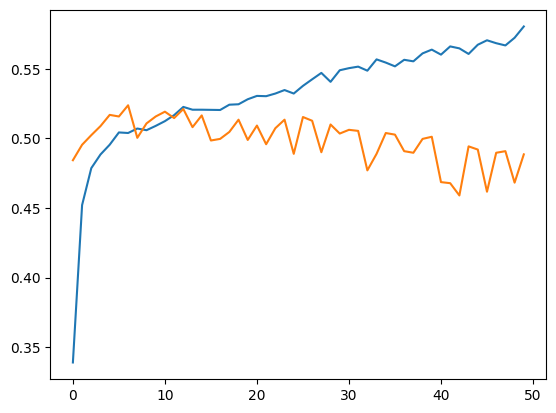

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

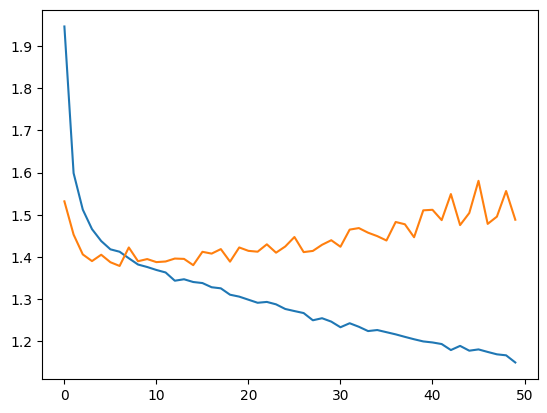

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

model2 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    tree_method='hist',
    device='cpu'
)

model2.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True
)

[0]	validation_0-mlogloss:1.51629	validation_1-mlogloss:1.51942
[1]	validation_0-mlogloss:1.49737	validation_1-mlogloss:1.51252
[2]	validation_0-mlogloss:1.47750	validation_1-mlogloss:1.50645
[3]	validation_0-mlogloss:1.45929	validation_1-mlogloss:1.50003
[4]	validation_0-mlogloss:1.44160	validation_1-mlogloss:1.49483
[5]	validation_0-mlogloss:1.42531	validation_1-mlogloss:1.48947
[6]	validation_0-mlogloss:1.40865	validation_1-mlogloss:1.48470
[7]	validation_0-mlogloss:1.39324	validation_1-mlogloss:1.48056
[8]	validation_0-mlogloss:1.37784	validation_1-mlogloss:1.47585
[9]	validation_0-mlogloss:1.36279	validation_1-mlogloss:1.47218
[10]	validation_0-mlogloss:1.34825	validation_1-mlogloss:1.46816
[11]	validation_0-mlogloss:1.33422	validation_1-mlogloss:1.46496
[12]	validation_0-mlogloss:1.32035	validation_1-mlogloss:1.46188
[13]	validation_0-mlogloss:1.30689	validation_1-mlogloss:1.45842
[14]	validation_0-mlogloss:1.29292	validation_1-mlogloss:1.45554
[15]	validation_0-mlogloss:1.28011	

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (9989, 768)
y_train: (9989,)
X_test: (2610, 768)
y_test: (2610,)


In [ ]:
results = model2.evals_result()

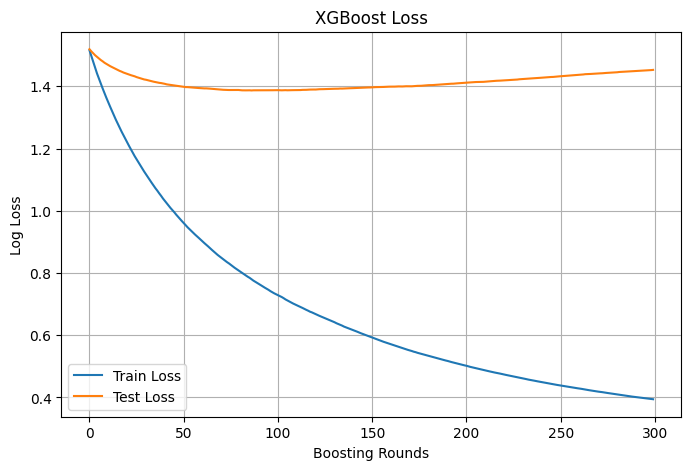

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(results['validation_0']['mlogloss'], label='Train Loss')
plt.plot(results['validation_1']['mlogloss'], label='Test Loss')

plt.title('XGBoost Loss')
plt.xlabel('Boosting Rounds')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
y_pred = model2.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.514176245210728


In [ ]:
import xgboost
print(xgboost.__version__)

3.2.0


In [ ]:
import librosa
import numpy as np
from moviepy.editor import VideoFileClip
import os

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [ ]:
import json

audio_config = {
    "n_mfcc": 40,
    "sr": 16000
}

with open("/content/drive/MyDrive/MELD/audio_config.json", "w") as f:
    json.dump(audio_config, f)

In [ ]:
#train
def get_mp4_path(dialogue_id, utterance_id, split):
    base = "/content/drive/MyDrive/MELD/MELD.Raw/MELD.Raw"
    return f"{base}/{split}/{split}_splits/dia{dialogue_id}_utt{utterance_id}.mp4"

In [ ]:
#test
def get_mp4_path(dialogue_id, utterance_id, split):
    base = "/content/drive/MyDrive/MELD/MELD.Raw/MELD.Raw"
    return f"{base}/{split}/output_repeated_splits_{split}/dia{dialogue_id}_utt{utterance_id}.mp4"

In [ ]:
import os
import numpy as np
import librosa
from moviepy.editor import VideoFileClip

def extract_mfcc(mp4_path, temp_wav="temp.wav"):
    try:
        video = VideoFileClip(mp4_path)

        if video.audio is None:
            return np.zeros(40)

        # safer conversion
        video.audio.write_audiofile(
            temp_wav,
            fps=16000,
            verbose=False,
            logger=None
        )

        y, sr = librosa.load(temp_wav, sr=16000)

        if len(y) == 0:
            return np.zeros(40)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfcc = np.mean(mfcc.T, axis=0)

        os.remove(temp_wav)
        return mfcc

    except Exception as e:
        print("Audio error:", mp4_path, e)
        return np.zeros(40)

In [ ]:
import tqdm

def build_audio_features(df, split):
    features = []

    for _, row in tqdm.tqdm(df.iterrows(), total=len(df)):
        path = get_mp4_path(row['Dialogue_ID'], row['Utterance_ID'], split)
        mfcc = extract_mfcc(path)
        features.append(mfcc)

    return np.array(features)

In [ ]:
train_audio = build_audio_features(train_df, "train")
# dev_audio = build_audio_features(dev_df, "dev")


  0%|          | 48/9989 [00:43<2:43:34,  1.01it/s]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1280
  warnings.warn(

  1%|          | 92/9989 [01:21<3:12:19,  1.17s/it]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1920
  warnings.warn(

 12%|█▏        | 1166/9989 [19:41<3:24:23,  1.39s/it]

Audio error: /content/drive/MyDrive/MELD/MELD.Raw/MELD.Raw/train/train_splits/dia125_utt3.mp4 MoviePy error: failed to read the duration of file /content/drive/MyDrive/MELD/MELD.Raw/MELD.Raw/train/train_splits/dia125_utt3.mp4.
Here are the file infos returned by ffmpeg:

ffmpeg version 7.0.2-static https://johnvansickle.com/ffmpeg/  Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 8 (Debian 8.3.0-6)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-debug --disable-ffplay --disable-indev=sndio --disable-outdev=sndio --cc=gcc --enable-fontconfig --enable-frei0r --enable-gnutls --enable-gmp --enable-libgme --enable-gray --enable-libaom --enable-libfribidi --enable-libass --enable-libvmaf --enable-libfreetype --enable-libmp3lame --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-librubberband --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libvorbis --enable-libopus --enable-libtheora --enable-libvidstab --e

100%|██████████| 9989/9989 [2:46:32<00:00,  1.00s/it]


In [ ]:
train_audio[0]

array([-189.46870422,   58.57240295,    8.82573223,   17.32963371,
         -8.6438427 ,    0.38934636,   -6.50828695,   -8.11374187,
          3.26838541,   -4.95209885,   -0.56444496,   -2.3633399 ,
         -8.00133133,    3.60191298,   -2.49206543,   -3.49715185,
         -0.72292936,   -3.34619689,   -2.91477609,   -1.22645783,
         -6.16001081,   -3.1484077 ,    0.42821357,   -0.55648756,
          0.96825957,   -3.95775342,   -3.73225188,   -2.62163901,
         -4.34876299,   -2.17966008,   -1.34794378,   -2.38433552,
         -0.1974716 ,   -1.51703894,   -2.44133592,   -3.02833891,
         -3.52994633,   -4.8673048 ,   -5.07837868,   -4.41589975])

In [ ]:
test_audio = build_audio_features(test_df, "test")

 55%|█████▌    | 1441/2610 [21:01<14:10,  1.37it/s]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1920
  warnings.warn(

100%|██████████| 2610/2610 [35:34<00:00,  1.22it/s]


In [ ]:
# np.save("/content/drive/MyDrive/MELD/train_audio.npy", train_audio)
# np.save("/content/drive/MyDrive/MELD/dev_audio.npy", dev_audio)
np.save("/content/drive/MyDrive/MELD/test_audio.npy", test_audio)

In [ ]:
import numpy as np

train_audio_loaded = np.load("/content/drive/MyDrive/MELD/train_audio.npy")
# dev_audio   = np.load("/content/drive/MyDrive/MELD/dev_audio.npy")
test_audio_loaded  = np.load("/content/drive/MyDrive/MELD/test_audio.npy")

In [ ]:
test_audio_loaded[0]

array([-3.1156958e+02,  9.5874199e+01, -5.5280538e+00,  7.2869688e-01,
       -7.5464211e+00, -2.5363340e+00, -1.2478306e+01, -1.0424906e+01,
       -1.7373514e+01, -5.2980242e+00,  9.3071866e-01, -6.6151590e+00,
       -1.3572955e+00, -2.2334933e+00, -2.3426242e+00, -8.0200090e+00,
       -6.2585683e+00, -6.6195908e+00, -6.6583304e+00, -2.1115463e+00,
       -4.1152897e+00, -5.3032866e+00, -3.0303783e+00, -3.6018262e+00,
       -2.2873650e+00,  4.1451171e-01,  1.2063521e+00,  1.0330808e+00,
        4.3113214e-01,  1.0810781e+00,  2.9452736e+00,  2.7770021e+00,
        1.0266213e+00, -4.2918739e-01, -9.7483146e-01, -3.1043541e-01,
       -5.4398882e-01,  5.3746946e-02, -1.7002972e+00, -1.8544644e+00],
      dtype=float32)

In [ ]:
print(train_audio.shape)
# print(dev_audio.shape)
print(test_audio.shape)

(9989, 40)
(1109, 40)
(2610, 40)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout , BatchNormalization , Input


In [ ]:
model = Sequential()
model.add(Input(shape=(40,)))
model.add(Dense(256,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())

model.add(Dense(128 , activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(7 , activation='softmax'))


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,343 (243.53 KB)

 Trainable params: 61,575 (240.53 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# train_audio = train_audio / np.max(np.abs(train_audio))
# dev_audio   = dev_audio / np.max(np.abs(dev_audio))
# test_audio  = test_audio / np.max(np.abs(test_audio))

  train_audio = train_audio / np.max(np.abs(train_audio))

  dev_audio   = dev_audio / np.max(np.abs(dev_audio))



In [ ]:
y_train = train_df['label'].values
y_dev   = dev_df['label'].values
y_test  = test_df['label'].values

In [ ]:
print("All zeros?", np.all(train_audio == 0))

All zeros? True


In [ ]:
history = model.fit(
    train_audio_loaded, y_train,
    validation_data=(test_audio, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.4252 - loss: 1.6669 - val_accuracy: 0.4659 - val_loss: 1.5685
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4589 - loss: 1.5581 - val_accuracy: 0.4839 - val_loss: 1.5264
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4704 - loss: 1.5284 - val_accuracy: 0.4778 - val_loss: 1.5205
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4723 - loss: 1.5198 - val_accuracy: 0.4755 - val_loss: 1.5163
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4724 - loss: 1.5074 - val_accuracy: 0.4793 - val_loss: 1.5010
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4728 - loss: 1.5046 - val_accuracy: 0.4870 - val_loss: 1.4888
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4753 - loss: 1.4911 - val_accuracy: 0.4816 - val_loss: 1.5047
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4748 - loss: 1.4854 - val_accuracy: 0.

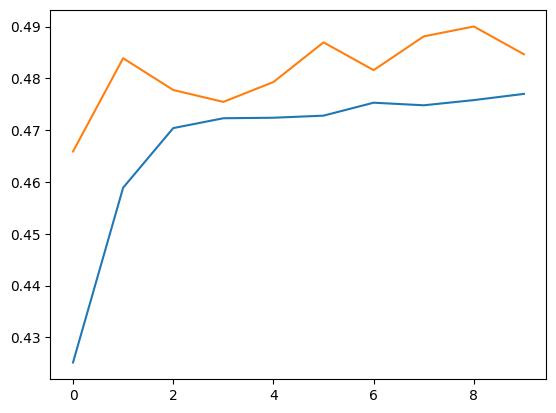

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


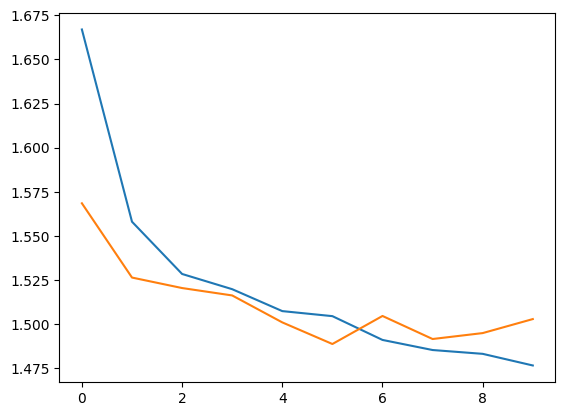

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


In [ ]:
train_audio_loaded = np.load("/content/drive/MyDrive/MELD/train_audio.npy")
X_train = np.load("/content/drive/MyDrive/MELD/train_bert.npy")
test_audio_loaded  = np.load("/content/drive/MyDrive/MELD/test_audio.npy")
X_test = np.load("/content/drive/MyDrive/MELD/test_bert.npy")

In [ ]:
print(X_train.shape)
print(train_audio_loaded.shape)

print(X_test.shape)
print(test_audio_loaded.shape)

(9989, 768)
(9989, 40)
(2610, 768)
(2610, 40)


In [ ]:
X_train_combined = np.concatenate([X_train, train_audio_loaded], axis=1)
X_test_combined  = np.concatenate([X_test, test_audio_loaded], axis=1)

In [ ]:
X_train_combined.shape

(9989, 808)

In [ ]:
X_test_combined.shape

(2610, 808)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2

model = Sequential()
model.add(Input(shape=(808,)))

# Block 1
model.add(Dense(512, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
# model.add(Dropout(0.2))

# Block 2
model.add(Dense(512, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
# model.add(Dropout(0.3))

# Block 3
model.add(Dense(256, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.2))

#Block 4
model.add(Dense(128, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.2))

# Output
model.add(Dense(7, activation='softmax'))

In [ ]:
model.compile(optimizer = 'adam' , loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       414,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,405,959 (5.36 MB)

 Trainable params: 1,403,143 (5.35 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

In [ ]:
history = model.fit(
    X_train_combined, y_train,
    validation_data=(X_test_combined, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.4497 - loss: 1.7307 - val_accuracy: 0.4812 - val_loss: 1.6385 - learning_rate: 0.0010
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4663 - loss: 1.6344 - val_accuracy: 0.4766 - val_loss: 1.5852 - learning_rate: 0.0010
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.4706 - loss: 1.5869 - val_accuracy: 0.3579 - val_loss: 1.7164 - learning_rate: 0.0010
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4786 - loss: 1.5490 - val_accuracy: 0.4985 - val_loss: 1.5264 - learning_rate: 0.0010
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.4928 - loss: 1.5166 - val_accuracy: 0.4716 - val_loss: 1.5562 - learning_rate: 0.0010
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.4974 - loss: 1.4817 - val_accuracy: 0.5038 - val_loss: 1.5006 - learning_rate: 0.0010
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.5033 - loss

In [ ]:
model.save("aud+text_model.keras")

In [ ]:
model.save('/content/drive/MyDrive/MELD/final_model.keras')

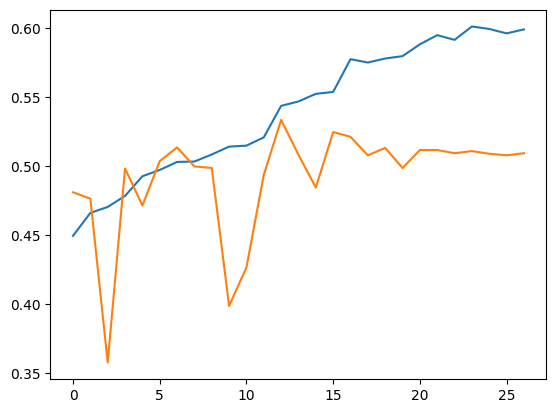

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


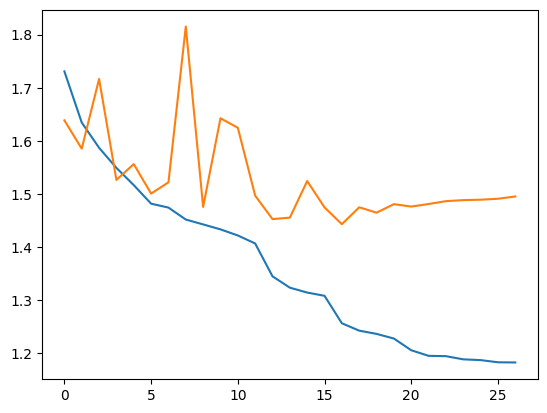

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


In [ ]:
import cv2
import numpy as np

def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total // max_frames)

    for i in range(0, total, step):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (224, 224))
        frames.append(frame)

    cap.release()
    return frames[:max_frames]

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

cnn = ResNet50(weights='imagenet', include_top=False, pooling='avg')

In [ ]:
import numpy as np
from tqdm import tqdm
from tensorflow.keras.applications.resnet50 import preprocess_input

def get_video_embeddings_batch(video_paths, cnn, batch_size=512):
    all_frames = []
    video_map = []

    # Step 1: collect frames
    for i, path in enumerate(tqdm(video_paths)):
        frames = extract_frames(path)

        if frames is None or len(frames) == 0:
            continue

        all_frames.extend(frames)
        video_map.extend([i] * len(frames))

    if len(all_frames) == 0:
        return np.zeros((len(video_paths), 2048))

    # Step 2: GPU batch inference
    all_frames = np.array(all_frames)
    all_frames = preprocess_input(all_frames)

    features = cnn.predict(all_frames, batch_size=batch_size, verbose=1)

    # Step 3: aggregate per video (SAFE)
    video_embeddings = [np.zeros(2048) for _ in range(len(video_paths))]

    for i in range(len(video_paths)):
        idxs = np.where(np.array(video_map) == i)[0]

        if len(idxs) > 0:
            video_embeddings[i] = np.mean(features[idxs], axis=0)

    return np.array(video_embeddings)

In [ ]:
def get_mp4_path(dialogue_id, utterance_id, split):
    base = "/content/drive/MyDrive/MELD/MELD.Raw/MELD.Raw"
    return f"{base}/{split}/{split}_splits/dia{dialogue_id}_utt{utterance_id}.mp4"

In [ ]:
train_df['video_path'] = train_df.apply(
    lambda row: get_mp4_path(row['Dialogue_ID'], row['Utterance_ID'], 'train'),
    axis=1
)

test_df['video_path'] = test_df.apply(
    lambda row: get_mp4_path(row['Dialogue_ID'], row['Utterance_ID'], 'test'),
    axis=1
)

In [ ]:
import os
import cv2

p = train_df['video_path'][0]

print("Exists:", os.path.exists(p))
cap = cv2.VideoCapture(p)
print("OpenCV opened:", cap.isOpened())

Exists: True
OpenCV opened: True


In [ ]:
print(train_df['video_path'][0])

/content/drive/MyDrive/MELD/MELD.Raw/MELD.Raw/train/train_splits/dia0_utt0.mp4


In [ ]:
import numpy as np
import gc
import torch

def process_in_chunks(video_paths, cnn, chunk_size=50, save_prefix="train_video"):
    total = len(video_paths)

    for i in range(0, total, chunk_size):
        print(f"\n🚀 Processing chunk {i} to {i + chunk_size}")

        chunk_paths = video_paths[i:i + chunk_size]

        embeddings = get_video_embeddings_batch(chunk_paths, cnn)

        save_path = f"/content/drive/MyDrive/MELD/Video/{save_prefix}_{i}.npy"
        np.save(save_path, embeddings)
        print(f"✅ Saved: {save_path}")

        # 🔥 CRITICAL: free memory
        del embeddings
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

In [ ]:
process_in_chunks(
    train_df['video_path'].tolist(),
    cnn,
    chunk_size=50,
    save_prefix="train_video"
)


🚀 Processing chunk 0 to 50


100%|██████████| 50/50 [02:05<00:00,  2.52s/it]


2/2 ━━━━━━━━━━━━━━━━━━━━ 104s 49s/step
✅ Saved: /content/drive/MyDrive/MELD/Video/train_video_0.npy

🚀 Processing chunk 50 to 100


100%|██████████| 50/50 [02:05<00:00,  2.50s/it]


2/2 ━━━━━━━━━━━━━━━━━━━━ 50s 48s/step
✅ Saved: /content/drive/MyDrive/MELD/Video/train_video_50.npy

🚀 Processing chunk 100 to 150


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 44s 43s/step
✅ Saved: /content/drive/MyDrive/MELD/Video/train_video_800.npy

🚀 Processing chunk 850 to 900


100%|██████████| 50/50 [02:34<00:00,  3.10s/it]


2/2 ━━━━━━━━━━━━━━━━━━━━ 53s 51s/step
✅ Saved: /content/drive/MyDrive/MELD/Video/train_video_850.npy

🚀 Processing chunk 900 to 950


100%|██████████| 50/50 [02:18<00:00,  2.77s/it]


1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

In [ ]:
import numpy as np
test_audio_loaded  = np.load("/content/drive/MyDrive/MELD/Video/train_video_0.npy")

In [ ]:
test_audio_loaded

array([[1.5609168e-01, 4.8130486e-02, 2.3334765e-01, ..., 9.0404645e-02,
        1.7249686e-01, 2.1612568e-01],
       [4.7656670e-01, 6.8711269e-01, 0.0000000e+00, ..., 3.7549999e-01,
        4.2425979e-02, 1.0746990e-01],
       [5.0036716e-01, 8.2759365e-02, 1.6762784e-01, ..., 4.4240352e-02,
        2.1824399e-01, 7.8721009e-02],
       ...,
       [1.2729758e+00, 3.5422251e-01, 1.1852043e-02, ..., 2.8215447e-02,
        4.8098904e-01, 9.2079021e-02],
       [2.5046382e+00, 1.9660714e-01, 3.2283820e-05, ..., 9.7130835e-02,
        5.4958385e-01, 4.6109721e-01],
       [2.2719655e+00, 2.6687512e-01, 1.6485821e-02, ..., 2.1994615e-01,
        7.9855907e-01, 5.6992024e-01]], dtype=float32)

In [ ]:
import numpy as np
import glob

files = sorted(glob.glob("/content/drive/MyDrive/MELD/Video/train_video_*.npy"))

X = []

for f in files:
    data = np.load(f)

    print(f, data.shape)  # must show (50, 2048)

    X.append(data)

X = np.vstack(X).astype(np.float32)

print("FINAL X shape:", X.shape)

/content/drive/MyDrive/MELD/Video/train_video_0.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_100.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_150.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_200.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_250.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_300.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_350.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_400.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_450.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_50.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_500.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_550.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_600.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_650.npy (50, 2048)
/content/drive/MyDrive/MELD/Video/train_video_700.npy (50, 2048)
/content/drive/MyDrive/MELD/

In [ ]:
train_df = train_df.iloc[:950]

In [ ]:
# X = np.mean(X, axis=1)  # temporal pooling

In [ ]:
# X = X # match embeddings

y = train_df['label'].values

In [ ]:
X.shape

(950, 2048)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Activation
from tensorflow.keras.regularizers import l2

model = Sequential([
    Input(shape=(2048,)),

    Dense(512, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),

    Dense(256, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),

    Dense(128, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),

    Dense(7, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217,799 (4.65 MB)

 Trainable params: 1,216,007 (4.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.1671 - loss: 2.4451 - val_accuracy: 0.4316 - val_loss: 1.8863
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2421 - loss: 1.8900 - val_accuracy: 0.4000 - val_loss: 1.8762
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2750 - loss: 1.7147 - val_accuracy: 0.3211 - val_loss: 1.9423
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.3461 - loss: 1.4666 - val_accuracy: 0.2211 - val_loss: 2.0261
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3789 - loss: 1.3884 - val_accuracy: 0.2684 - val_loss: 2.0160
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4303 - loss: 1.2718 - val_accuracy: 0.2842 - val_loss: 1.9989
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4816 - loss: 1.1710 - val_accuracy: 0.2158 - val_loss: 2.2453


In [ ]:
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("Example sample shape:", X_train[0].shape)


X shape: (950,)
X_train shape: (760,)
Example sample shape: ()


In [ ]:
import numpy as np

sample = np.load(files[0], allow_pickle=True)

print(sample.shape)
print(type(sample))
print(sample[0].shape if len(sample) > 0 else "empty")

(50, 2048)
<class 'numpy.ndarray'>
(2048,)


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_train dtype:", X_train.dtype)
print("First sample:", X_train[0])
print("First sample shape:", np.shape(X_train[0]))

X_train shape: (760,)
y_train shape: (760,)
X_train dtype: float32
First sample: 0.5544114
First sample shape: ()


In [ ]:
import numpy as np
import glob

base_paths = [
    "/content/drive/MyDrive/MELD/VishalCollab",
    "/content/drive/MyDrive/MELD/VishalCollab (1)",
    "/content/drive/MyDrive/MELD/VishalCollab (2)",
    "/content/drive/MyDrive/MELD/Video"
]

files = []
for base in base_paths:
    files.extend(sorted(glob.glob(base + "/**/*.npy", recursive=True)))

files = sorted(files)

X = []

for f in files:
    data = np.load(f)

    # print(f, data.shape)  # expect (50, 2048)

    X.append(data)

X = np.vstack(X).astype(np.float32)

print("FINAL X shape:", X.shape)

FINAL X shape: (9989, 2048)


In [ ]:
save_path = "/content/drive/MyDrive/MELD/X_embeddings.npy"

np.save(save_path, X)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/MELD/X_embeddings.npy


In [ ]:
train_audio_loaded = np.load("/content/drive/MyDrive/MELD/train_audio.npy")


In [ ]:
train_text_bert = np.load("/content/drive/MyDrive/MELD/train_bert.npy")

In [ ]:
print(X.shape)
print(train_audio_loaded.shape)
print(train_text_bert.shape)

(9989, 2048)
(9989, 40)
(9989, 768)


In [ ]:
X_fused = np.concatenate(
    [X, train_audio_loaded, train_text_bert],
    axis=1
)

In [ ]:
from sklearn.preprocessing import StandardScaler

X_fused = StandardScaler().fit_transform(X_fused)

In [ ]:
y = train_df['label'];

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fused,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2

model = Sequential()
model.add(Input(shape=(2856,)))

# Block 1
model.add(Dense(512, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))

# Block 2
model.add(Dense(256, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

# Block 3
model.add(Dense(128, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.2))

# Output
model.add(Dense(7, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,462,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,976,455 (7.54 MB)

 Trainable params: 1,974,663 (7.53 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.4443 - loss: 1.7580 - val_accuracy: 0.4737 - val_loss: 1.7389
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4795 - loss: 1.6162 - val_accuracy: 0.4812 - val_loss: 1.6225
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5112 - loss: 1.5261 - val_accuracy: 0.4663 - val_loss: 1.6648
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5219 - loss: 1.4715 - val_accuracy: 0.4588 - val_loss: 1.6464
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5474 - loss: 1.3980 - val_accuracy: 0.4600 - val_loss: 1.6716
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5679 - loss: 1.3442 - val_accuracy: 0.4663 - val_loss: 1.7433
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5937 - loss: 1.2869 - val_accuracy: 0.4725 - val_loss: 1.7518
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6167 - loss: 1.2201 - val_accuracy: 

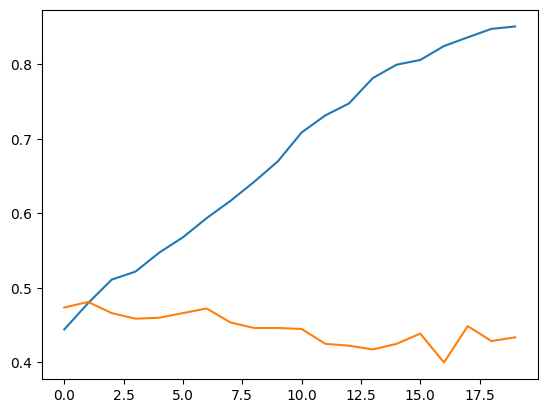

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

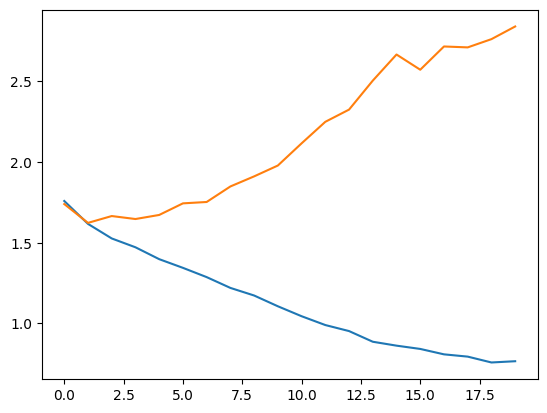

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
label_map = {
    'anger': 0,
    'disgust': 1,
    'fear': 2,
    'joy': 3,
    'neutral': 4,
    'sadness': 5,
    'surprise': 6
}

train_df["label"] = train_df["Emotion"].map(label_map)

In [ ]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["Utterance"].tolist(),
    train_df["label"].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=train_df["label"]
)

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_enc = tokenizer(train_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
val_enc   = tokenizer(val_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")

In [ ]:
import torch

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
from torch.utils.data import DataLoader

train_dataset = EmotionDataset(train_enc, train_labels)
val_dataset   = EmotionDataset(val_enc, val_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=7
)

model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

best_f1 = 0
patience = 2
counter = 0
epochs = 8

for epoch in range(epochs):

    # ---------------- TRAIN ----------------
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    # ---------------- VALIDATION ----------------
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = accuracy_score(true, preds)
    f1 = f1_score(true, preds, average="macro")

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", total_loss / len(train_loader))
    print("Val Acc:", acc)
    print("Val F1:", f1)

    # ---------------- EARLY STOPPING ----------------
    if f1 > best_f1:
        best_f1 = f1
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1
Train Loss: 1.2069735691693755
Val Acc: 0.6356356356356356
Val F1: 0.38275810342054417

Epoch 2
Train Loss: 0.9599217476780623
Val Acc: 0.6036036036036037
Val F1: 0.38450486390468575

Epoch 3
Train Loss: 0.6984580845482568
Val Acc: 0.6136136136136137
Val F1: 0.39956099529542194

Epoch 4
Train Loss: 0.46229468871676943
Val Acc: 0.5955955955955956
Val F1: 0.404422800713603

Epoch 5
Train Loss: 0.3201150378300162
Val Acc: 0.6056056056056056
Val F1: 0.4203800196213742

Epoch 6
Train Loss: 0.23381099063203772
Val Acc: 0.6206206206206206
Val F1: 0.44009329965370086

Epoch 7
Train Loss: 0.1919210211481995
Val Acc: 0.5995995995995996
Val F1: 0.4240858938961722

Epoch 8
Train Loss: 0.16810893640087857
Val Acc: 0.5875875875875876
Val F1: 0.41791620080643505
Early stopping triggered.


In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

encodings = tokenizer(
    train_df["Utterance"].tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
import torch

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

dataset = EmotionDataset(encodings, train_df["label"].values)

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=7
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 10

model.train()

for epoch in range(epochs):
    total_loss = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.4f}")

Epoch 1/10 | Avg Loss: 0.4606
Epoch 2/10 | Avg Loss: 0.2963
Epoch 3/10 | Avg Loss: 0.2351


KeyboardInterrupt: 

In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score

# ---------------------------
# CONFIG
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_labels = 7
epochs = 8
batch_size = 8
lr = 2e-5

# ---------------------------
# LABEL MAP (MELD)
# ---------------------------
label_map = {
    'anger': 0,
    'disgust': 1,
    'fear': 2,
    'joy': 3,
    'neutral': 4,
    'sadness': 5,
    'surprise': 6
}

train_df["label"] = train_df["Emotion"].map(label_map)

# ---------------------------
# TRAIN / VAL SPLIT
# ---------------------------
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["Utterance"].tolist(),
    train_df["label"].tolist(),
    test_size=0.1,
    random_state=42,
    stratify=train_df["label"]
)

# ---------------------------
# TOKENIZER
# ---------------------------
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_enc = tokenizer(train_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
val_enc   = tokenizer(val_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")

# ---------------------------
# DATASET
# ---------------------------
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_enc, train_labels)
val_dataset   = Dataset(val_enc, val_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)

# ---------------------------
# MODEL
# ---------------------------
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
).to(device)

# ---------------------------
# CLASS WEIGHTS (IMPORTANT FIX)
# ---------------------------
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

weights = torch.tensor(weights, dtype=torch.float).to(device)
loss_fn = CrossEntropyLoss(weight=weights)

# ---------------------------
# OPTIMIZER + SCHEDULER
# ---------------------------
optimizer = AdamW(model.parameters(), lr=lr)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=1
)

# ---------------------------
# TRAINING LOOP
# ---------------------------
best_f1 = 0
patience = 2
counter = 0

for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = accuracy_score(true, preds)
    f1 = f1_score(true, preds, average="macro")

    scheduler.step(f1)

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", total_loss / len(train_loader))
    print("Val Acc:", acc)
    print("Val F1:", f1)

    # -------- EARLY STOPPING --------
    if f1 > best_f1:
        best_f1 = f1
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1
Train Loss: 1.6104972036919984
Val Acc: 0.5835835835835835
Val F1: 0.39599179431620934

Epoch 2
Train Loss: 1.2698377676414214
Val Acc: 0.5345345345345346
Val F1: 0.41821057715187193


KeyboardInterrupt: 

In [ ]:
import torch
import numpy as np
import pandas as pd

from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

# ---------------------------
# CONFIG
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 8
batch_size = 8
lr = 3e-5
num_labels = 7

# ---------------------------
# LABEL MAP
# ---------------------------
label_map = {
    'anger': 0,
    'disgust': 1,
    'fear': 2,
    'joy': 3,
    'neutral': 4,
    'sadness': 5,
    'surprise': 6
}

train_df["label"] = train_df["Emotion"].map(label_map)

# ---------------------------
# SPLIT
# ---------------------------
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["Utterance"].tolist(),
    train_df["label"].tolist(),
    test_size=0.1,
    stratify=train_df["label"],
    random_state=42
)

# ---------------------------
# TOKENIZER
# ---------------------------
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_enc = tokenizer(train_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
val_enc   = tokenizer(val_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")

# ---------------------------
# DATASET
# ---------------------------
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_enc, train_labels)
val_dataset   = Dataset(val_enc, val_labels)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)

# ---------------------------
# MODEL
# ---------------------------
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
)

model.to(device)

# ---------------------------
# FREEZE ALL LAYERS
# ---------------------------
for param in model.bert.parameters():
    param.requires_grad = False

# ---------------------------
# UNFREEZE LAST 3 LAYERS
# ---------------------------
for layer in model.bert.encoder.layer[-6:]:
    for param in layer.parameters():
        param.requires_grad = True

# ---------------------------
# UNFREEZE CLASSIFIER
# ---------------------------
for param in model.classifier.parameters():
    param.requires_grad = True

# ---------------------------
# CLASS WEIGHTS
# ---------------------------
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

weights = torch.tensor(weights, dtype=torch.float).to(device)
loss_fn = CrossEntropyLoss(weight=weights)

# ---------------------------
# OPTIMIZER
# ---------------------------
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr
)

# ---------------------------
# TRAIN LOOP
# ---------------------------
best_f1 = 0
patience = 2
counter = 0

for epoch in range(epochs):

    # -------- TRAIN --------
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # -------- VALIDATION --------
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    acc = accuracy_score(true, preds)
    f1 = f1_score(true, preds, average="macro")

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", total_loss / len(train_loader))
    print("Val Acc:", acc)
    print("Val F1:", f1)

    # -------- EARLY STOPPING --------
    if f1 > best_f1:
        best_f1 = f1
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1
Train Loss: 1.618202106755399
Val Acc: 0.5175175175175175
Val F1: 0.38220155547477136

Epoch 2
Train Loss: 1.3434367672510419
Val Acc: 0.5325325325325325
Val F1: 0.4076562474048849

Epoch 3
Train Loss: 1.0668982352889094
Val Acc: 0.5635635635635635
Val F1: 0.4067808193603133

Epoch 4
Train Loss: 0.7889638522513926
Val Acc: 0.5495495495495496
Val F1: 0.42311745477175033

Epoch 5
Train Loss: 0.5762425602059082
Val Acc: 0.5645645645645646
Val F1: 0.41473698891886457

Epoch 6
Train Loss: 0.43262951640458613
Val Acc: 0.5645645645645646
Val F1: 0.42297132868842563
Early stopping triggered.
